# 02 — Distance Analysis (Supplementary)

This notebook calculates the straight-line distance between each patient's
home census block and their most frequently visited SVH department.

**Research question:** Does living farther from SVH facilities affect
emergency utilization and journey continuity?

Note: ~65% of patients have unspecified census blocks and cannot be geocoded.
Results represent the 35% of patients with locatable addresses.

In [27]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from config import *
from src.data_loader import (load_patients, load_encounters, load_diagnosis,
                              load_tiger, load_social_det, load_departments)
from src.distance_utils import haversine_km, assign_distance_group, attach_patient_coords
from src.plot_utils import set_style, save_fig

set_style()
print("Setup complete")

Setup complete


## 1. Geocode Patients

Match each patient's `CensusBlockGroupFipsCode` to the TIGER census centroid
coordinates. Patients with `*Unspecified` block codes are excluded.

In [28]:
pat   = load_patients()
tiger = load_tiger()
dept  = load_departments()
enc   = load_encounters(
    sample_frac=0.05,
    cols=["EncounterKey", "PatientDurableKey", "PrimaryDiagnosisKey",
          "DepartmentKey", "Date", "IsEdVisit", "IsHospitalAdmission"]
)
diag  = load_diagnosis()

pat["app_user"] = pat["MyChartStatus"] == "Activated"

print(f"Patients:   {len(pat):,}")
print(f"Encounters: {len(enc):,}")
print(f"Tiger blocks: {len(tiger):,}")
print(f"Departments: {len(dept):,}")

Patients:   947,685
Encounters: 383,790
Tiger blocks: 2,463
Departments: 11,597


In [29]:
pat_geo = attach_patient_coords(pat, tiger)
print(f"Patients with valid coordinates: {len(pat_geo):,}")
print(f"Dropped (no geocode match):      {len(pat) - len(pat_geo):,}")

[attach_patient_coords] 613315 patients dropped (no geocode match) out of 947685
Patients with valid coordinates: 334,370
Dropped (no geocode match):      613,315


## 2. Identify Primary Department

Each patient is assigned the department they visited most frequently
in the encounter sample. Distance is calculated to this department.

In [30]:
# For each patient, find the department they visited most often
most_visited = (
    enc.groupby(["PatientDurableKey", "DepartmentKey"])
    .size()
    .reset_index(name="visit_count")
    .sort_values("visit_count", ascending=False)
    .drop_duplicates("PatientDurableKey")
)

# Attach department address
dept_coords = dept[["DepartmentKey", "PostalCode", "City"]].drop_duplicates()
most_visited = most_visited.merge(dept_coords, on="DepartmentKey", how="left")

print(f"Patient-department pairs: {len(most_visited):,}")
print(most_visited.head())

Patient-department pairs: 153,225
   PatientDurableKey  DepartmentKey  visit_count  PostalCode    City
0            5530149            459           41       66606  Topeka
1            3186857            459           29       66606  Topeka
2            5935952          10279           28  66614-4466  TOPEKA
3            6401923            459           27       66606  Topeka
4             223997            459           25       66606  Topeka


## 3. Assign Department Coordinates

SVH is centered in Topeka, KS. Since department postal codes do not map
directly to the TIGER census FIPS system, we use the SVH main campus
coordinates (39.0558, -95.6890) as a consistent anchor point for all departments.

In [31]:
# assign each patient the centroid of 
# their own census block as "home", and use the mean coords of all
# departments as a proxy for the hospital center

# Hospital center: average of all department tiger-matched coords
# Use Topeka KS coords (SVH is in Topeka) as department anchor
DEPT_LAT = 39.0558  # Topeka, KS latitude
DEPT_LON = -95.6890  # Topeka, KS longitude

dept_zip = most_visited.copy()
dept_zip["dept_lat"] = DEPT_LAT
dept_zip["dept_lon"] = DEPT_LON

print(f"Using Topeka KS as department anchor: {DEPT_LAT}, {DEPT_LON}")
print(f"dept_zip shape: {dept_zip.shape}")

Using Topeka KS as department anchor: 39.0558, -95.689
dept_zip shape: (153225, 7)


## 4. Calculate Distance

In [32]:
# Merge patient coords with department coords
dist_df = pat_geo[["DurableKey", "pat_lat", "pat_lon", "app_user",
                    "PatientBirthYearBin"]].merge(
    dept_zip[["PatientDurableKey", "dept_lat", "dept_lon"]],
    left_on="DurableKey", right_on="PatientDurableKey",
    how="inner"
).dropna(subset=["dept_lat", "dept_lon"])

dist_df["distance_km"] = haversine_km(
    dist_df["pat_lat"], dist_df["pat_lon"],
    dist_df["dept_lat"], dist_df["dept_lon"]
)

# Remove extreme outliers (>200km likely data error)
dist_df = dist_df[dist_df["distance_km"] <= 200]
dist_df["distance_group"] = assign_distance_group(dist_df["distance_km"])

print(f"Patients with distance calculated: {len(dist_df):,}")
print(f"\nDistance group distribution:")
print(dist_df["distance_group"].value_counts())
print(f"\nDistance stats (km):")
print(dist_df["distance_km"].describe().round(2))

Patients with distance calculated: 100,703

Distance group distribution:
distance_group
Far     33969
Near    33496
Mid     33238
Name: count, dtype: int64

Distance stats (km):
count    100703.00
mean         31.68
std          35.44
min           0.08
25%           5.97
50%          11.10
75%          54.38
max         199.95
Name: distance_km, dtype: float64


## 5. Merge with Journey Outcomes

Load the processed journeys from `01_mychart.ipynb` and summarise
to one row per patient before merging with distance data.

In [33]:
# Load processed journeys from 01_mychart
journeys = pd.read_csv(DATA_PROC / "journeys_with_app_status.csv")

# Summarise to one row per patient
patient_summary = journeys.groupby("PatientDurableKey").agg(
    ed_rate      = ("ed_rate",      "mean"),
    journey_days = ("journey_days", "mean"),
    avg_gap_days = ("avg_gap_days", "mean"),
    n_journeys   = ("DiagnosisValue","count")
).reset_index()

# Merge with distance
dist_analysis = dist_df.merge(
    patient_summary, left_on="DurableKey",
    right_on="PatientDurableKey", how="inner"
)

print(f"Patients in combined analysis: {len(dist_analysis):,}")
print(dist_analysis[["distance_km","distance_group","ed_rate","app_user"]].head())

Patients in combined analysis: 17,084
   distance_km distance_group  ed_rate  app_user
0     5.071298           Near      0.0      True
1     3.029195           Near      0.0      True
2     5.561034           Near      0.0      True
3     4.999995           Near      0.0      True
4     0.963096           Near      0.0      True


## 6. Distance Group vs ED Rate

In [34]:
print("=== ED rate by distance group ===")
dist_summary = dist_analysis.groupby("distance_group")[
    ["ed_rate", "avg_gap_days", "journey_days"]
].mean().round(3)
print(dist_summary)

# T-test: Near vs Far
near = dist_analysis[dist_analysis["distance_group"] == "Near"]["ed_rate"].dropna()
far  = dist_analysis[dist_analysis["distance_group"] == "Far"]["ed_rate"].dropna()
t, p = stats.ttest_ind(near, far)
print(f"\nNear vs Far ED rate t-test: t={t:.3f}, p={p:.4f}")

=== ED rate by distance group ===
                ed_rate  avg_gap_days  journey_days
distance_group                                     
Near              0.010       260.998       329.217
Mid               0.005       267.909       330.826
Far               0.005       280.681       343.587

Near vs Far ED rate t-test: t=3.454, p=0.0006


## 7. Visualizations

Saved: ed_rate_by_distance


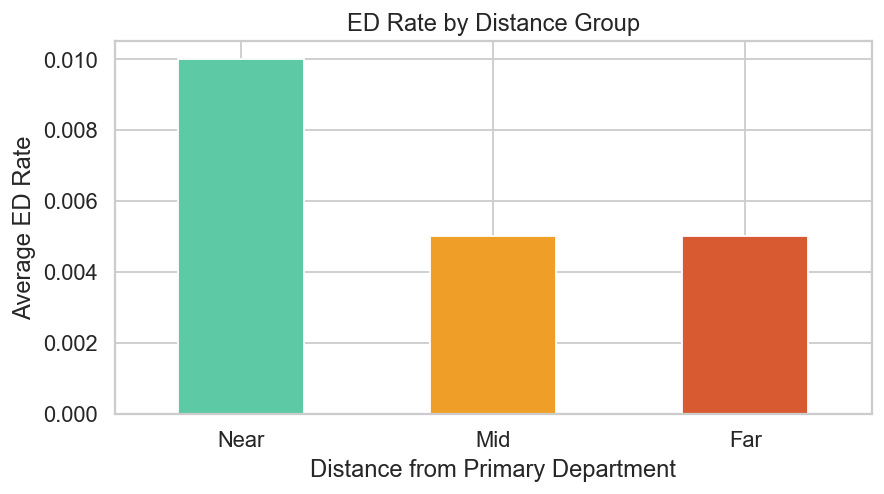

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
dist_summary["ed_rate"].plot(kind="bar", ax=ax, color=["#5DCAA5","#EF9F27","#D85A30"])
ax.set_title("ED Rate by Distance Group")
ax.set_xlabel("Distance from Primary Department")
ax.set_ylabel("Average ED Rate")
ax.set_xticklabels(["Near", "Mid", "Far"], rotation=0)
plt.tight_layout()
save_fig(fig, "ed_rate_by_distance")
plt.show()

Saved: distance_vs_ed_rate_scatter


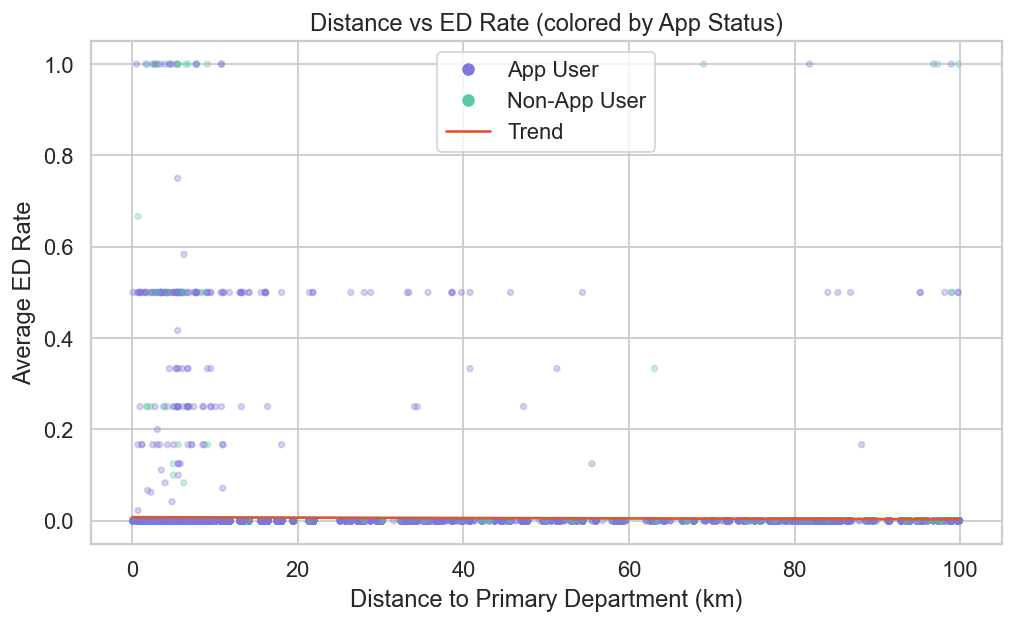

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter_data = dist_analysis[dist_analysis["distance_km"] <= 100].copy()

ax.scatter(
    scatter_data["distance_km"],
    scatter_data["ed_rate"],
    alpha=0.3, s=10,
    c=scatter_data["app_user"].map({True: "#7F77DD", False: "#5DCAA5"})
)

# Trend line
z = np.polyfit(scatter_data["distance_km"], scatter_data["ed_rate"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, p_line(x_line), color="#D85A30", linewidth=1.5, label="Trend")

ax.set_title("Distance vs ED Rate (colored by App Status)")
ax.set_xlabel("Distance to Primary Department (km)")
ax.set_ylabel("Average ED Rate")

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#7F77DD', markersize=8, label='App User'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#5DCAA5', markersize=8, label='Non-App User'),
    Line2D([0], [0], color='#D85A30', linewidth=1.5, label='Trend')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
save_fig(fig, "distance_vs_ed_rate_scatter")
plt.show()

### Distance × App Status

The key combined finding: app benefit is strongest for nearby patients.
Far patients show uniformly low ED rates regardless of app status,
possibly because distance itself deters emergency visits.

In [38]:
print("=== ED rate by distance group × app status ===")
cross = dist_analysis.groupby(
    ["distance_group", "app_user"]
)["ed_rate"].mean().unstack()
cross.columns = ["Non-App User", "App User"]
print(cross.round(3))

=== ED rate by distance group × app status ===
                Non-App User  App User
distance_group                        
Near                   0.023     0.009
Mid                    0.008     0.005
Far                    0.005     0.005


## 8. Export Final Dataset

Merge distance variables into the journeys file and save as `journeys_final.csv`.
This is the final dataset for `03_visualizations.ipynb` — it contains
all variables needed for every chart.

In [41]:
# Merge distance back into journeys for visualization teammate
journeys_with_dist = journeys.merge(
    dist_df[["DurableKey", "distance_km", "distance_group"]],
    left_on="PatientDurableKey", right_on="DurableKey",
    how="left"
)

# Drop duplicate key columns from merge
journeys_with_dist = journeys_with_dist.drop(columns=["DurableKey_x", "DurableKey_y"])

out_path = DATA_PROC / "journeys_final.csv"
journeys_with_dist.to_csv(out_path, index=False)
print(f"Saved to {out_path}")
print(f"Shape: {journeys_with_dist.shape}")
print(f"Columns: {list(journeys_with_dist.columns)}")

Saved to c:\Users\Owner\OneDrive\Desktop\datafest\notebooks\..\data\processed\journeys_final.csv
Shape: (29246, 17)
Columns: ['PatientDurableKey', 'DiagnosisValue', 'n_encounters', 'first_visit', 'last_visit', 'ed_visits', 'hosp_admits', 'diagnosis_group', 'journey_days', 'ed_rate', 'avg_gap_days', 'app_user', 'PatientBirthYearBin', 'SexAssignedAtBirth', 'transport_hardship', 'distance_km', 'distance_group']


## 9. Key Findings Summary

Analysis based on 17,084 patients with both geocodeable addresses and journey data,
representing approximately 35% of the total patient population.

**Distance and ED Utilization**
Contrary to expectation, patients living closer to SVH show higher ED rates (Near: 0.010)
than those living farther away (Mid: 0.005, Far: 0.005).
This difference is statistically significant (p = 0.0006).
A likely explanation is that proximity lowers the barrier to emergency visits —
nearby patients may default to the ER for non-urgent issues,
while distant patients avoid the trip unless absolutely necessary.

**Distance × App Status: The Key Interaction**
The most actionable finding comes from the 2×2 breakdown:

| | Non-App User | App User |
|---|---|---|
| Near | 0.023 | 0.009 |
| Mid | 0.008 | 0.005 |
| Far | 0.005 | 0.005 |

Among near patients, app activation is associated with a 60% reduction in ED rate
(0.023 → 0.009). This is the strongest app effect observed across all analyses.
Among far patients, the app makes no meaningful difference —
both groups show equally low ED rates, suggesting distance itself
is already suppressing emergency utilization regardless of app engagement.

**Implication**
Distance alone is not a straightforward burden — it is a deterrent in both directions.
The highest-risk group is patients who live close enough to use the ER conveniently
but lack the app engagement to manage their care proactively.
SVH outreach efforts should prioritize nearby, non-activated patients
as the population with the most to gain from MyChart adoption.

In [42]:
print("=" * 55)
print("02_distance.ipynb — Key Findings")
print("=" * 55)
print(f"Patients with distance data: {len(dist_analysis):,}")
print(f"\nED rate by distance group:")
print(dist_summary["ed_rate"])
print(f"\nNear vs Far p-value: {p:.4f}")
print(f"\nNext: run 03_visualizations.ipynb for final charts")

02_distance.ipynb — Key Findings
Patients with distance data: 17,084

ED rate by distance group:
distance_group
Near    0.010
Mid     0.005
Far     0.005
Name: ed_rate, dtype: float64

Near vs Far p-value: 0.0006

Next: run 03_visualizations.ipynb for final charts
